In [37]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [38]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


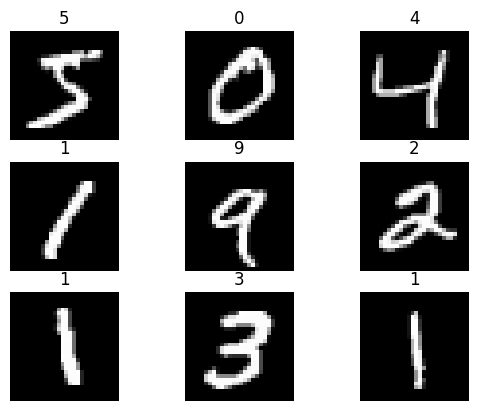

In [40]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

In [41]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [42]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 52ms/step - accuracy: 0.9297 - loss: 0.2293 - val_accuracy: 0.9809 - val_loss: 0.0538
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9762 - loss: 0.0808 - val_accuracy: 0.9875 - val_loss: 0.0341
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 51ms/step - accuracy: 0.9824 - loss: 0.0614 - val_accuracy: 0.9884 - val_loss: 0.0340
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 49ms/step - accuracy: 0.9850 - loss: 0.0504 - val_accuracy: 0.9895 - val_loss: 0.0290
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - accuracy: 0.9872 - loss: 0.0416 - val_accuracy: 0.9915 - val_loss: 0.0262


In [45]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9915 - loss: 0.0262
Test Accuracy: 0.9915000200271606


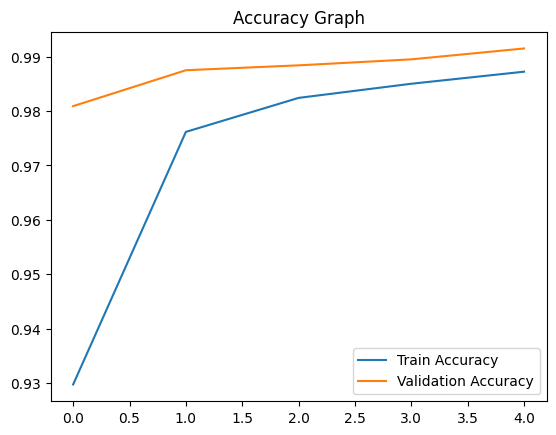

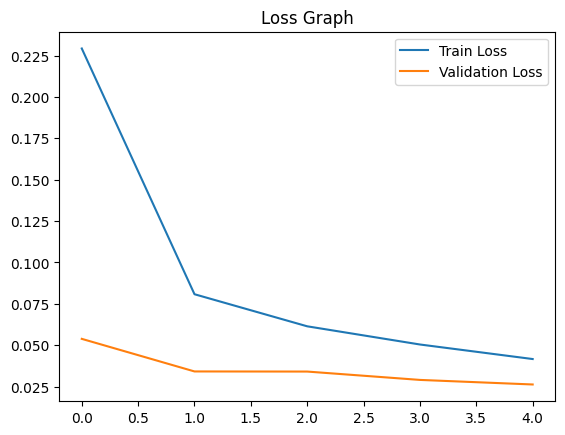

In [46]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("Loss Graph")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


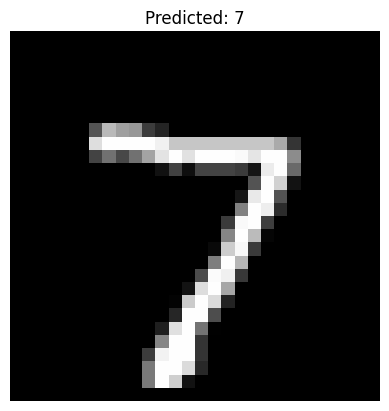

In [47]:
index = 0
sample = X_test[index].reshape(1,28,28,1)

prediction = model.predict(sample)
predicted_digit = np.argmax(prediction)

plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.axis('off')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Predicted Digit: 7
Actual Digit: 7


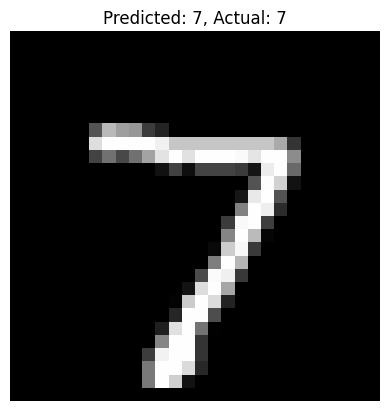

In [48]:
predictions = model.predict(X_test)

predicted_digit = np.argmax(predictions[0])

actual_digit = np.argmax(y_test[0])

print("Predicted Digit:", predicted_digit)
print("Actual Digit:", actual_digit)

plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_digit}, Actual: {actual_digit}")
plt.axis('off')
plt.show()